In [107]:
import pandas as pd
import seaborn as sns
import numpy as np

# How do customer experiences connect to broader business outcomes?

## Basic Exploration

### Customer Support Tickets

In [108]:
customer_support_tickets = pd.read_csv(
    "/home/rushik-sriramoju/AtlassianDatathon/customer_support_tickets.csv"
)

customer_support_tickets.head()
print(customer_support_tickets.columns)

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Status', 'Resolution',
       'Ticket Priority', 'Ticket Channel', 'First Response Time',
       'Time to Resolution', 'Customer Satisfaction Rating'],
      dtype='str')


In [109]:
customer_support_tickets["Ticket Subject"]

0                    Product setup
1                      Integration
2                  Network problem
3                   Account access
4                        Data loss
                   ...            
8464          Installation support
8465                Refund request
8466                Account access
8467                 Payment issue
8468    Device compatibility issue
Name: Ticket Subject, Length: 8469, dtype: str

In [110]:
customer_support_tickets["Customer Satisfaction Rating"].max()

np.float64(5.0)

In [111]:
product_usage = pd.read_csv(
    "/home/rushik-sriramoju/AtlassianDatathon/product_usage.csv"
)

product_usage.head()

,Customer ID,Product,Month,Active Days,Sessions,Product Actions,Collaborators,Integrations Used
0,CUST00001,Loom,2023-01,3,7,49,12,3
1,CUST00001,Loom,2023-02,4,7,22,4,4
2,CUST00001,Loom,2023-03,5,10,37,5,3
3,CUST00001,Loom,2023-04,4,7,47,12,1
4,CUST00001,Loom,2023-05,5,10,34,4,3


In [112]:
customer_support_tickets.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,Jira,22-03-2021,Technical issue,Product setup,Pending Customer Response,NaN,Critical,Social media,01-06-2023 12:15,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,Confluence,22-05-2021,Technical issue,Integration,Pending Customer Response,NaN,Critical,Chat,01-06-2023 16:45,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Trello,14-07-2020,Technical issue,Network problem,Closed,Case maybe show recently my computer follow.,Low,Social media,01-06-2023 11:14,01-06-2023 18:05,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Loom,13-11-2020,Billing inquiry,Account access,Closed,Try capital clearly never color toward story.,Low,Social media,01-06-2023 07:29,01-06-2023 01:57,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Bitbucket,04-02-2020,Billing inquiry,Data loss,Closed,West decision evidence bit.,Low,Email,01-06-2023 00:12,01-06-2023 19:53,1.0


In [113]:
customer_support_tickets = customer_support_tickets.drop(columns=["Customer Email", "Ticket ID", "Customer Gender", "Date of Purchase", "Customer Age"])

In [114]:
customer_support_tickets.head()

,Customer Name,Product Purchased,Ticket Type,Ticket Subject,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,Marisa Obrien,Jira,Technical issue,Product setup,Pending Customer Response,NaN,Critical,Social media,01-06-2023 12:15,NaN,NaN
1,Jessica Rios,Confluence,Technical issue,Integration,Pending Customer Response,NaN,Critical,Chat,01-06-2023 16:45,NaN,NaN
2,Christopher Robbins,Trello,Technical issue,Network problem,Closed,Case maybe show recently my computer follow.,Low,Social media,01-06-2023 11:14,01-06-2023 18:05,3.0
3,Christina Dillon,Loom,Billing inquiry,Account access,Closed,Try capital clearly never color toward story.,Low,Social media,01-06-2023 07:29,01-06-2023 01:57,3.0
4,Alexander Carroll,Bitbucket,Billing inquiry,Data loss,Closed,West decision evidence bit.,Low,Email,01-06-2023 00:12,01-06-2023 19:53,1.0


In [115]:
customer_support_tickets["Ticket Type"].value_counts()

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

In [116]:
technical_issue = customer_support_tickets[customer_support_tickets["Ticket Type"] == "Technical issue"]
technical_issue.head()

,Customer Name,Product Purchased,Ticket Type,Ticket Subject,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,Marisa Obrien,Jira,Technical issue,Product setup,Pending Customer Response,NaN,Critical,Social media,01-06-2023 12:15,NaN,NaN
1,Jessica Rios,Confluence,Technical issue,Integration,Pending Customer Response,NaN,Critical,Chat,01-06-2023 16:45,NaN,NaN
2,Christopher Robbins,Trello,Technical issue,Network problem,Closed,Case maybe show recently my computer follow.,Low,Social media,01-06-2023 11:14,01-06-2023 18:05,3.0
8,Nicolas Wilson,Trello,Technical issue,Installation support,Pending Customer Response,NaN,Low,Social media,01-06-2023 10:32,NaN,NaN
12,Tamara Hahn,Confluence,Technical issue,Device compatibility issue,Pending Customer Response,NaN,Low,Chat,01-06-2023 19:03,NaN,NaN


## Which Products have the highest number of cancellation/refund tickets?

In [117]:
customer_support_tickets["Ticket Type"].value_counts()

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

### Cancellation Requests

In [118]:
cancellation_requests = customer_support_tickets[customer_support_tickets["Ticket Type"] == "Cancellation request"]
cancellation_requests.head()


,Customer Name,Product Purchased,Ticket Type,Ticket Subject,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
5,Rebecca Fleming,Loom,Cancellation request,Payment issue,Open,NaN,Low,Social media,NaN,NaN,NaN
10,Joseph Moreno,Bitbucket,Cancellation request,Data loss,Closed,Measure tonight surface feel forward.,High,Phone,01-06-2023 17:46,31-05-2023 23:51,1.0
21,Tanner Conley,Trello,Cancellation request,Installation support,Pending Customer Response,NaN,Critical,Social media,31-05-2023 23:57,NaN,NaN
22,Stephanie Nelson DVM,Jira,Cancellation request,Email delivery problem,Open,NaN,Medium,Social media,NaN,NaN,NaN
27,Michael Mcdowell,Confluence,Cancellation request,Product setup,Open,NaN,High,Phone,NaN,NaN,NaN


Text(0.5, 1.0, 'Cancellation Request')

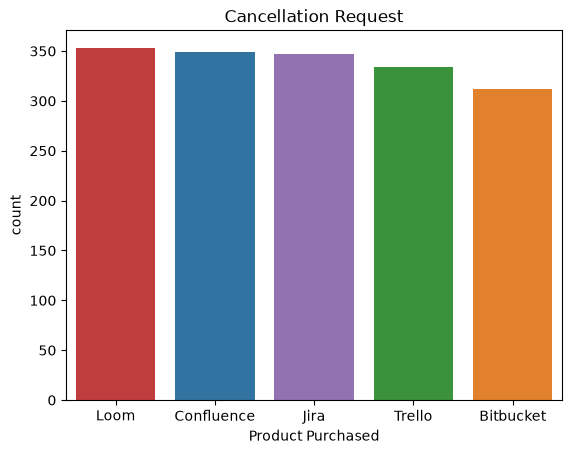

In [119]:
# Which product has the most amount of cancellation requests
sns.countplot(data=cancellation_requests,
              x="Product Purchased",
              hue="Product Purchased",
              order=["Loom", "Confluence", "Jira", "Trello", "Bitbucket"],
              hue_order=["Confluence","Bitbucket", "Trello", "Loom",  "Jira" ]).set_title("Cancellation Request")

## Find the percentage of cancellation requests per product

In [151]:
# get the all the requests
all = customer_support_tickets

# get the closed ones
cancellation = all[["Product Purchased", "Ticket Type"]]
cancellation_df = cancellation.groupby(["Product Purchased", "Ticket Type"]).size().reset_index(name="count")

# calculate the percentage within each Product Purchased group
cancellation_df["percentage"] = (
    cancellation_df.groupby("Product Purchased")["count"]
    .transform(lambda x: (x / x.sum()) * 100)
)
cancellation_df = cancellation_df.sort_values(["Product Purchased", "Ticket Type", "percentage"], ascending=False)
cancellation_df[cancellation_df["Ticket Type"] == "Cancellation request"].sort_values("percentage", ascending=False)


,Product Purchased,Ticket Type,count,percentage
16,Loom,Cancellation request,353,21.669736
21,Trello,Cancellation request,334,20.528580
1,Bitbucket,Cancellation request,312,19.561129
11,Jira,Cancellation request,347,19.418019
6,Confluence,Cancellation request,349,19.060623


In [120]:
# get the all the requests
all = customer_support_tickets

# get the closed ones
closed = all[all["Ticket Status"] == "Closed"]
closed = all[["Product Purchased", "Ticket Type", "Ticket Subject", "Customer Satisfaction Rating"]]
closed_df = closed.groupby(["Product Purchased", "Ticket Type"])["Customer Satisfaction Rating"].mean().reset_index().sort_values(["Product Purchased", "Ticket Type", "Customer Satisfaction Rating"], ascending=True)
closed_df


,Product Purchased,Ticket Type,Customer Satisfaction Rating
0,Bitbucket,Billing inquiry,2.924731
1,Bitbucket,Cancellation request,3.109890
2,Bitbucket,Product inquiry,2.937500
3,Bitbucket,Refund request,2.896825
4,Bitbucket,Technical issue,2.892562
5,Confluence,Billing inquiry,3.037383
6,Confluence,Cancellation request,2.836957
7,Confluence,Product inquiry,3.000000
8,Confluence,Refund request,3.129032
9,Confluence,Technical issue,3.041322


In [121]:
closed_df[closed_df["Ticket Type"] == "Cancellation request"].sort_values("Customer Satisfaction Rating")

,Product Purchased,Ticket Type,Customer Satisfaction Rating
6,Confluence,Cancellation request,2.836957
16,Loom,Cancellation request,3.000000
21,Trello,Cancellation request,3.063636
1,Bitbucket,Cancellation request,3.109890
11,Jira,Cancellation request,3.125000


In [122]:
# get the all the requests
all = customer_support_tickets

# get the closed ones
closed = all[all["Ticket Status"] == "Closed"]
closed = all[["Product Purchased", "Ticket Type", "Ticket Subject", "Customer Satisfaction Rating"]]
closed_df = closed.groupby(["Product Purchased"])["Customer Satisfaction Rating"].mean().reset_index().sort_values(["Customer Satisfaction Rating"], ascending=True)
closed_df

,Product Purchased,Customer Satisfaction Rating
0,Bitbucket,2.944972
2,Jira,2.962264
4,Trello,2.974729
1,Confluence,3.017762
3,Loom,3.057196


### Refunds + Cancellations

In [163]:
# get the all the requests
all = customer_support_tickets

# get the closed ones
refund_cancel = all[["Product Purchased", "Ticket Type"]]
refund_cancel["Churn"] = refund_cancel["Ticket Type"].isin(["Refund request", "Cancellation request"])
refund_cancel.drop(columns=["Ticket Type"])
refund_cancel_df = refund_cancel.groupby(["Product Purchased", "Churn"]).size().reset_index(name="count")

# calculate the percentage within each Product Purchased group
refund_cancel_df["percentage"] = (
    refund_cancel_df.groupby("Product Purchased")["count"]
    .transform(lambda x: (x / x.sum()) * 100)
)

refund_cancel_df = refund_cancel_df.sort_values(["Product Purchased", "Churn", "percentage"], ascending=False)
refund_cancel_df[refund_cancel_df["Churn"]].sort_values("percentage", ascending=False)


,Product Purchased,Churn,count,percentage
7,Loom,True,687,42.173112
9,Trello,True,682,41.917640
1,Bitbucket,True,668,41.880878
3,Confluence,True,726,39.650464
5,Jira,True,684,38.276441


In [174]:
# get the all the requests
all = customer_support_tickets

# get the closed ones
closed = all[all["Ticket Status"] == "Closed"]
closed["Churn"] = closed["Ticket Type"].isin(["Cancellation request", "Refund request"])

closed = closed[["Product Purchased", "Churn", "Customer Satisfaction Rating"]]

closed_df = closed.groupby(["Product Purchased", "Churn"])["Customer Satisfaction Rating"].mean().reset_index().sort_values(["Customer Satisfaction Rating"], ascending=True)
closed_df[closed_df["Churn"]].sort_values("Customer Satisfaction Rating")


,Product Purchased,Churn,Customer Satisfaction Rating
7,Loom,True,2.906780
9,Trello,True,2.965368
1,Bitbucket,True,2.986175
3,Confluence,True,3.004630
5,Jira,True,3.037736


In [177]:
closed_df[closed_df["Churn"] == False].sort_values("Customer Satisfaction Rating")

,Product Purchased,Churn,Customer Satisfaction Rating
0,Bitbucket,False,2.916129
4,Jira,False,2.919137
8,Trello,False,2.981424
2,Confluence,False,3.025937
6,Loom,False,3.173203


In [156]:
closed = customer_support_tickets[customer_support_tickets["Ticket Status"] == "Closed"]
print("Number of No-ratings in Closed Tickets")
int(closed["Customer Satisfaction Rating"].isna().sum())

Number of No-ratings in Closed Tickets


0

In [ ]:
# get the all the requests
all = customer_support_tickets

# get the closed ones
closed = all[all["Ticket Status"] == "Closed"]
closed = all[["Product Purchased", "Ticket Type", "Ticket Subject", "Customer Satisfaction Rating"]]
closed_df = closed.groupby(["Product Purchased"])["Customer Satisfaction Rating"].mean().reset_index().sort_values(["Customer Satisfaction Rating"], ascending=True)
closed_df

,Product Purchased,Customer Satisfaction Rating
0,Bitbucket,2.944972
2,Jira,2.962264
4,Trello,2.974729
1,Confluence,3.017762
3,Loom,3.057196


In [126]:
refund_requests = customer_support_tickets[customer_support_tickets["Ticket Type"] == "Refund request"]
refund_requests.head()


,Customer Name,Product Purchased,Ticket Type,Ticket Subject,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
7,Denise Lee,Confluence,Refund request,Loading issue,Open,NaN,Critical,Social media,NaN,NaN,NaN
9,William Dawson,Loom,Refund request,Payment issue,Pending Customer Response,NaN,Critical,Phone,01-06-2023 09:25,NaN,NaN
19,Jeffrey Robertson,Trello,Refund request,Software bug,Closed,Wish mouth build resource though.,Low,Chat,01-06-2023 00:46,01-06-2023 20:29,5.0
20,Suzanne Holmes,Loom,Refund request,Payment issue,Pending Customer Response,NaN,High,Chat,01-06-2023 05:08,NaN,NaN
33,Timothy Lyons,Bitbucket,Refund request,Device compatibility issue,Closed,However financial development significant came...,Critical,Social media,01-06-2023 02:01,01-06-2023 18:25,5.0
